# v_weinstein_adx 全量回测 2016-2026
当前优化参数：ADX>25, 追踪止盈15%, 放量2.0x, $2000/笔

In [1]:
import sys, yaml, pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timezone
from pathlib import Path

sys.path.insert(0, '.')
import re

# Load stock universe
us_stocks_set = set()
with open("UNIVERSE.md") as f:
    content = f.read()
for section in re.split(r"^## ", content, flags=re.MULTILINE):
    lines = section.split("\n")
    title = lines[0].strip()
    in_us = title.startswith("板块 S：") or title.startswith("板块 N：")
    if in_us:
        for line in lines:
            if line.startswith("|"):
                parts = [p.strip() for p in line.split("|")]
                if len(parts) >= 2 and re.match(r"^[A-Z0-9]{1,6}(\.[A-Z0-9]{1,5})?$", parts[1]):
                    us_stocks_set.add(parts[1])
us_stocks = sorted(us_stocks_set)
print(f"Stock pool: {len(us_stocks)} stocks")

# Load config
with open("config.yaml") as f:
    config = yaml.safe_load(f)

from data.fetcher import fetch
from backtest.engine import Trade, _ensure_utc, _get_close
from events import EventQueue
from strategies.registry import get_strategy

Stock pool: 501 stocks


In [2]:
# Parameters
INITIAL_CAPITAL = 50_000.0
POSITION_SIZE   = 2_000.0
START = datetime(2016, 1, 1, tzinfo=timezone.utc)
END   = datetime(2026, 3, 27, tzinfo=timezone.utc)

# Load SPY benchmark
spy_df = pickle.load(open(Path("data/cache/SPY.pkl"), 'rb'))
spy_df.index = spy_df.index.tz_localize(None)
spy_mask = (spy_df.index >= START.replace(tzinfo=None)) & (spy_df.index <= END.replace(tzinfo=None))
spy_prices = spy_df['close'][spy_mask]
spy_equity = spy_prices / spy_prices.iloc[0]
spy_equity.index = spy_equity.index.tz_localize(None)

# Load strategy config
cfg = config['strategies']['v_weinstein_adx'].copy()
cfg['_strategy_id'] = 'v_weinstein_adx'
print("Strategy params:", {k: v for k, v in cfg.items() if not k.startswith('_')})

Strategy params: {'name': 'Weinstein Stage 2 + ADX 增强（优化版）', 'description': 'ADX>25 + 追踪止盈15% + 放量2.0x，年化+6.9%，夏普0.61（vs 基线0.52）', 'sma_long': 150, 'trend_lookback': 30, 'pivot_lookback': 30, 'min_breakout_pct': 0.005, 'volume_mult': 2.0, 'rsi_max': 85, 'adx_threshold': 25, 'market_filter': False, 'spy_bear_stop_loss': 0.05, 'stop_loss_pct': 0.07, 'trailing_stop_pct': 0.15, 'time_stop_days': 30, 'time_stop_min_gain': 0.05}


In [3]:
# Fetch data and run backtest
total_days = (END - START).days + 300
md = fetch(us_stocks, history_days=total_days, end_date=END)
if not md: raise RuntimeError("no data")
for bm, syms in [("SPY",["SPY"]),("ASHR",["ASHR"]),("EWT",["EWT"])]:
    if bm not in md:
        d = fetch(syms, history_days=total_days, end_date=END)
        if d and bm in d: md[bm] = d[bm]

ref = next(iter(md.values())).index
if ref.tzinfo is None: ref = ref.tz_localize("UTC")
days = ref[(ref >= START) & (ref <= END)]

strategy_cls = get_strategy('v_weinstein_adx')
strategy = strategy_cls(cfg, md)
queue = EventQueue()

sliced = {}
for sym, df in md.items():
    idx = df.index
    if idx.tzinfo is None:
        df = df.copy()
        df.index = idx.tz_localize("UTC")
    sliced[sym] = df

open_t, all_t = {}, []
cash = float(INITIAL_CAPITAL)
active = {}
records = []
rebal_count = 0

for date in days:
    dt = date.to_pydatetime()
    if dt.tzinfo is None: dt = dt.replace(tzinfo=timezone.utc)

    # Calculate daily portfolio value
    pv = 0.0
    for sym, pos in list(active.items()):
        df = sliced.get(sym)
        if df is not None:
            mask = df.index <= dt
            if mask.sum() >= 1:
                cur_price = float(df["close"][mask].iloc[-1])
                pv += cur_price * pos['shares']
    equity = cash + pv
    util = pv / equity * 100 if equity > 0 else 0
    records.append({'date': dt, 'cash': cash, 'pos_value': pv, 'equity': equity, 'num_pos': len(active), 'util': util})

    for sig in strategy.run_date(dt, queue):
        sym, dir_ = sig.symbol, sig.data["direction"]
        if dir_ == "buy" and sym not in open_t and sym not in active:
            ep = _get_close(md, sym, dt, strategy)
            if not ep: continue
            if cash < POSITION_SIZE: continue
            shares = POSITION_SIZE / ep
            active[sym] = {'shares': shares, 'cost': POSITION_SIZE, 'entry_price': ep, 'entry_date': dt}
            cash -= POSITION_SIZE
            t = Trade(symbol=sym, entry_date=dt, entry_price=ep, entry_reason=sig.data.get("reason",""))
            open_t[sym] = t; all_t.append(t)
        elif dir_ == "sell" and sym in open_t:
            xp = _get_close(md, sym, dt, strategy)
            if not xp: continue
            t = open_t.pop(sym); t.close(dt, xp, sig.data.get("reason",""))
            if sym in active:
                p2 = active.pop(sym)
                cash += POSITION_SIZE + (xp - t.entry_price) * p2['shares']

# Force close all positions at end
for sym, t in list(open_t.items()):
    xp = _get_close(md, sym, END, strategy)
    if xp:
        t.close(END, xp, "end")
        if sym in active:
            p2 = active.pop(sym)
            cash += POSITION_SIZE + (xp - t.entry_price) * p2['shares']

if records:
    records[-1] = {'date': records[-1]['date'], 'cash': cash, 'pos_value': 0, 'equity': cash, 'num_pos': 0, 'util': 0}

dates = pd.to_datetime([r['date'] for r in records]).tz_localize(None)
equity_series = pd.Series([r['equity'] for r in records], index=dates)
util_series = pd.Series([r['util'] for r in records], index=dates)
pos_series = pd.Series([r['num_pos'] for r in records], index=dates)
print(f"Backtest complete. {len(records)} days, {len([t for t in all_t if t.is_closed])} trades.")

[数据] 本地直接使用 501 只，增量更新 0 只，全量下载 0 只
[数据] 分类耗时: 0.7秒
[数据] 成功获取 501/501 只股票的数据
[数据] 总耗时: 0.7秒
[数据] 本地直接使用 1 只，增量更新 0 只，全量下载 0 只
[数据] 分类耗时: 0.0秒
[数据] 成功获取 1/1 只股票的数据
[数据] 总耗时: 0.0秒
[数据] 本地直接使用 1 只，增量更新 0 只，全量下载 0 只
[数据] 分类耗时: 0.0秒
[数据] 成功获取 1/1 只股票的数据
[数据] 总耗时: 0.0秒
[数据] 本地直接使用 1 只，增量更新 0 只，全量下载 0 只
[数据] 分类耗时: 0.0秒
[数据] 成功获取 1/1 只股票的数据
[数据] 总耗时: 0.0秒
Backtest complete. 3944 days, 951 trades.


In [4]:
# Calculate metrics
closed = [t for t in all_t if t.is_closed]
tr = float(equity_series.iloc[-1] / equity_series.iloc[0] - 1)
yrs = (END - START).days / 365.25
ann = (1+tr)**(1/yrs)-1 if yrs > 0 else 0
wins = [t for t in closed if t.pnl_pct > 0]
losses = [t for t in closed if t.pnl_pct <= 0]
wr = len(wins)/len(closed) if closed else 0
aw = np.mean([t.pnl_pct for t in wins]) if wins else 0
al = abs(np.mean([t.pnl_pct for t in losses])) if losses else 1
plr = (aw*len(wins))/(al*len(losses)) if losses else 0
cmax = equity_series.cummax(); dd = (equity_series-cmax)/cmax; mdd = abs(dd.min())
dr = equity_series.pct_change().dropna()
sharpe = (dr.mean()*252)/(dr.std()*np.sqrt(252)) if dr.std()>0 else 0

print(f"\n{'='*60}")
print(f"  v_weinstein_adx Full Backtest 2016-2026")
print(f"{'='*60}")
print(f"  Total Return: {tr*100:+.1f}%  Ann: {ann*100:+.1f}%  MDD: {mdd*100:.1f}%  Sharpe: {sharpe:.2f}")
print(f"  Win Rate: {wr*100:.1f}%  P/L: {plr:.2f}  Trades: {len(closed)}")
print(f"  Final Equity: ${equity_series.iloc[-1]:,.0f}")


  v_weinstein_adx Full Backtest 2016-2026
  Total Return: +75.3%  Ann: +5.6%  MDD: 12.6%  Sharpe: 0.58
  Win Rate: 53.6%  P/L: 1.86  Trades: 951
  Final Equity: $87,627


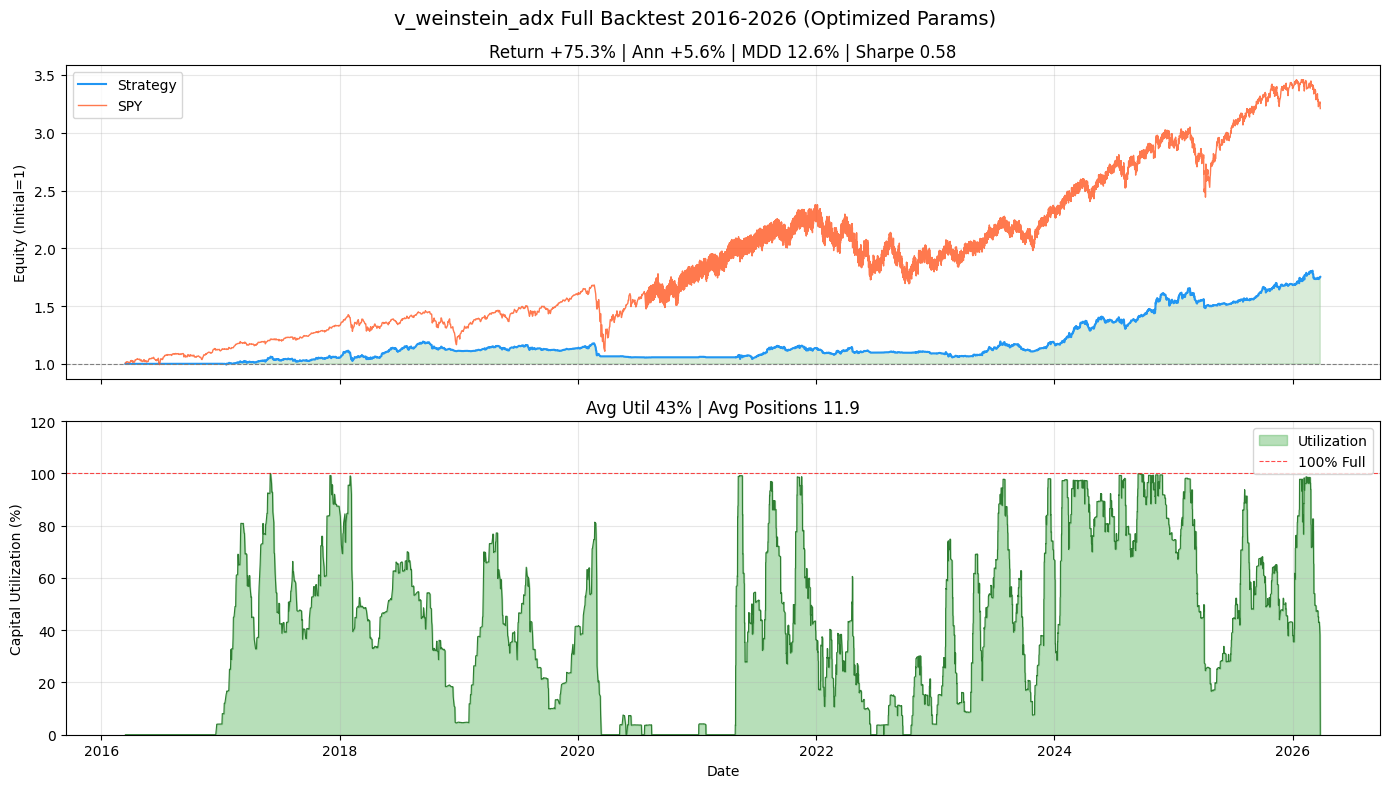

In [5]:
# Plot equity curve and utilization
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('v_weinstein_adx Full Backtest 2016-2026 (Optimized Params)', fontsize=14)

# Top: Equity curve
ax1 = axes[0]
ax1.plot(equity_series.index, equity_series/INITIAL_CAPITAL, label='Strategy', color='#2196F3', linewidth=1.5)
spy_eq = spy_equity.loc[equity_series.index[0]:equity_series.index[-1]]
spy_eq = spy_eq.reindex(equity_series.index, method='ffill').fillna(1.0)
ax1.plot(equity_series.index, spy_eq, label='SPY', color='#FF5722', linewidth=1, alpha=0.8)
ax1.axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Equity (Initial=1)')
ax1.legend(loc='upper left')
ax1.set_title(f'Return {tr*100:+.1f}% | Ann {ann*100:+.1f}% | MDD {mdd*100:.1f}% | Sharpe {sharpe:.2f}')
ax1.grid(True, alpha=0.3)
ax1.fill_between(equity_series.index, 1, equity_series/INITIAL_CAPITAL,
                  where=equity_series/INITIAL_CAPITAL >= 1, alpha=0.15, color='green')
ax1.fill_between(equity_series.index, 1, equity_series/INITIAL_CAPITAL,
                  where=equity_series/INITIAL_CAPITAL < 1, alpha=0.15, color='red')

# Bottom: Capital utilization
ax2 = axes[1]
ax2.fill_between(equity_series.index, 0, util_series, alpha=0.4, color='#4CAF50', label='Utilization')
ax2.plot(equity_series.index, util_series, color='#2E7D32', linewidth=0.8)
ax2.axhline(y=100, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='100% Full')
ax2.set_ylabel('Capital Utilization (%)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right')
ax2.set_title(f'Avg Util {util_series.mean():.0f}% | Avg Positions {pos_series.mean():.1f}')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(util_series.max() * 1.1, 120))

plt.tight_layout()
plt.show()